In [185]:
import warnings 
warnings.filterwarnings('ignore')

# Document load 
from langchain_community.document_loaders import PyPDFLoader 
loader  = PyPDFLoader('Why_Language_Models_Hallucinate_Explainer.pdf')
pages = loader.load()

In [186]:
from langchain_text_splitters import RecursiveCharacterTextSplitter 
import hashlib

# Split Data 

spliter = RecursiveCharacterTextSplitter(chunk_size=1400 , chunk_overlap=180)
text_spliter = spliter.split_documents(pages)
chunks = [i.page_content for i in text_spliter]
metadata = [i.metadata for i in text_spliter]
ids = [hashlib.md5(chunk.encode('utf-8')).hexdigest() for chunk in chunks]
print(f'print first 5 ids : {ids[:2]}')

chunks

print first 5 ids : ['cf3e5cf4108cc13eb93ba2143e5f6109', 'd8a31efd9960f02cdb598610f552b8d2']


['1\n Why Language Models Hallucinate: A Statistical Account\n A Summary and Synthesis of Current Research  |  Compiled 2026\nABSTRACT\n Hallucination — the tendency of large language models (LLMs) to produce fluent, confident, and factually\nwrong statements — is often described as mysterious or unpredictable. Recent theoretical work, most\nnotably by Kalai, Nachum, Vempala, and Zhang (2025), argues the opposite: hallucination is a natural and\nlargely predictable consequence of how models are trained and graded, not an unexplained quirk of scale.\nThis document synthesizes that argument alongside supporting survey literature, covering the pretraining\norigins of factual error, why post-training and benchmarking fail to eliminate it, the specific error categories\nthat resist correction regardless of model size, and the mitigation strategies — including retrieval-augmented\ngeneration and evaluation reform — currently under study.\n1. Framing the Problem\nHallucination is usually disc

In [187]:
import chromadb 
from chromadb.utils.embedding_functions import SentenceTransformerEmbeddingFunction 
embedding_function = SentenceTransformerEmbeddingFunction(model_name="all-MiniLM-L6-v2")

# client and collection create 
client = chromadb.PersistentClient(path="./Hybrid_RAG")
collection = client.get_or_create_collection(name="Hybrid_RAG",embedding_function=embedding_function)

if collection.count()==0:
    collection.add(
        ids=ids,
        documents=chunks , metadatas=metadata
    )
collection.count()

9

In [188]:
# LLM call 
import os 
from dotenv import load_dotenv 
from langchain_groq import ChatGroq 
load_dotenv()
try:
    key = os.getenv('GROQ_API_KEY')
    print(bool(key))
except Exception as e:
    print(str(e))
    
Groq = ChatGroq(model="openai/gpt-oss-120b")

test = Groq.invoke("hello llama?")
test.content

True


'Hello! 👋 How can I assist you today?'

In [189]:
from rank_bm25 import BM25Okapi

token_corpus = [chunk.split() for chunk in chunks]

tokens = BM25Okapi(token_corpus)

print(type(chunks))
print(type(tokens))

<class 'list'>
<class 'rank_bm25.BM25Okapi'>


In [190]:
from langchain_community.tools import DuckDuckGoSearchRun  
from langchain_core.tools import tool

@tool 
def Web_search(query:str):
    """ If the given question isnt related to the retriveal_chunking then it transfer to the web_Search """
    search = DuckDuckGoSearchRun()
    return search.run(query)


import numexpr
@tool 
def calculator(exec:str):
    """ Do the user given operations Like ANY arithmetic Calculations """
    try : 
        response = numexpr.evaluate(exec)
        return str(response)
    except Exception as e :
        return f"error {e}"


tools=[calculator  ,Web_search]    

print({t.name:t for t in tools})

{'calculator': StructuredTool(name='calculator', description='Do the user given operations Like ANY arithmetic Calculations', args_schema=<class 'langchain_core.utils.pydantic.calculator'>, func=<function calculator at 0x129905e80>), 'Web_search': StructuredTool(name='Web_search', description='If the given question isnt related to the retriveal_chunking then it transfer to the web_Search', args_schema=<class 'langchain_core.utils.pydantic.Web_search'>, func=<function Web_search at 0x129906770>)}


In [191]:
from langgraph.graph import StateGraph , START ,END 
from langgraph.graph.message import add_messages 
from typing import TypedDict , Annotated 

class State(TypedDict):
    messages: Annotated[list, add_messages]
    retrieved_context: list
    relevance: str
    search_query: str
    retries: int  
    
Build = StateGraph(State)
Build

In [192]:
from langchain_core.messages import AIMessage

def Hybrid_Retrive(state:State):
    query_re = state.get("search_query") or state["messages"][0].content
    
    # Thats Vector DB retrival 
    result = collection.query(
    query_texts=[query_re],
    n_results=5
)

    distances = result["distances"][0]
    documents = result["documents"][0]
    
    print("RESULT:", result)
    print("DISTANCES:", result["distances"])
    print("DOCUMENTS:", result["documents"])
    
    threshold = 1.5

    dense_chunks = []

    for dis, doc in zip(distances, documents):
        if dis < threshold:
            dense_chunks.append(doc)
            
    # Thats Hybrid RAG Retrival using indexing 
    scores = tokens.get_scores(query_re.split())

    def get_keywords(scores, k=10):

        index = list(enumerate(scores))

        sorted_index = sorted(
        index,
        key=lambda x: x[1],
        reverse=True
        )

        return [doc for doc, score in sorted_index[:k] if score > 0]

    keywords = get_keywords(scores, k=10)

    get_docs = [
    chunks[i]
    for i in keywords
    ]
    
    
    rrf_token = {}

    for rank, doc in enumerate(dense_chunks):

        rrf_token[doc] = (
        rrf_token.get(doc, 0)
        + 1 / (rank + 60)
        )

    for rank, doc in enumerate(get_docs):

        rrf_token[doc] = (
        rrf_token.get(doc, 0)
        + 1 / (rank + 60))

    merge = sorted(
    rrf_token.items(),
    key=lambda x: x[1],
    reverse=True)

    top_docs = [
    doc
    for doc, score in merge[:5]]
    
    return {'messages':
        [AIMessage(content=(f'use this context to give users questions : {query_re}'))]  ,
        'retrieved_context':top_docs
        }


In [193]:
def relevence_check(state: State):

    query = state["messages"][0].content

    documents = state.get("retrieved_context", [])

    context = "\n\n".join(documents)

    prompt = f"""
You are a retrieval relevance grader.

User question:
{query}

Retrieved context:
{context}

Determine whether the retrieved documents are relevant
enough to answer the user's question.

Return ONLY:

YES

or

NO
"""

    response = Groq.invoke(prompt).content.strip().upper()

    if response == "YES":
        relevance = "yes"
    else:
        relevance = "no"

    return {
        "relevance": relevance
    }

In [194]:
def rewrite_query(state: State):

    query = state["messages"][0].content

    prompt = f"""
Rewrite this user's question into a better search query
for retrieving relevant documents.

Original question:
{query}

Return ONLY the rewritten search query.
"""

    new_query = Groq.invoke(prompt).content.strip()

    return {
        "search_query": new_query,
        "retries": state.get("retries", 0) + 1
    }

In [195]:
# routing 
def relevence_route(state: State):
    if state["relevance"] == "yes" or state.get("retries", 0) >= 2:
        return "LLM_tools"
    return "rewrite_query"

In [196]:
tool_bind = Groq.bind_tools(tools)

from langchain_core.messages import HumanMessage

def LLM_tools(state: State):

    context = state.get("retrieved_context", [])

    context_text = "\n\n".join(context)

    messages = state["messages"]

    prompt = f"""
Use the following retrieved context to answer the user's question.

Retrieved context:
{context_text}

If the context is insufficient, use an appropriate tool.

User question:
{messages[0].content}
"""

    response = tool_bind.invoke(
        [HumanMessage(content=prompt)]
    )

    return {
        "messages": response
    }


In [197]:
from langgraph.types import interrupt
def approve_node(state: State):

    decision = interrupt({
        "type": "approval",
        "reason": "Model is about to answer user's question"
    })

    return state

In [198]:
from langgraph.prebuilt import tools_condition, ToolNode

Graph = StateGraph(State)

Graph.add_node("retrival", Hybrid_Retrive)

Graph.add_node("relevance_check", relevence_check)

Graph.add_node("rewrite_query", rewrite_query)

Graph.add_node("LLM_tools", LLM_tools)

Graph.add_node("tools", ToolNode(tools))

Graph.add_node("approval", approve_node)

In [199]:
from langgraph.checkpoint.sqlite import SqliteSaver

memory_context = SqliteSaver.from_conn_string(
    "langgraph_memory.db"
)

memory = memory_context.__enter__()

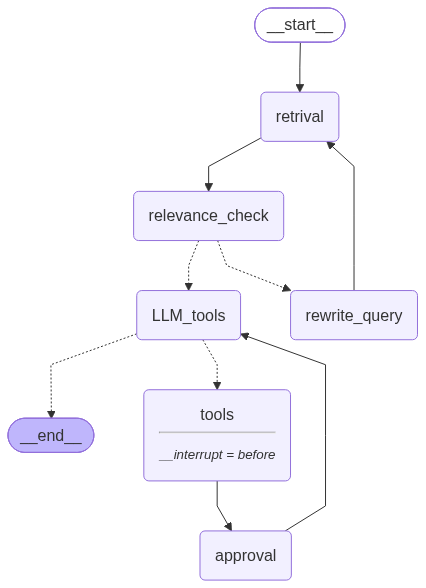

In [200]:
Graph.add_edge(START, "retrival")

Graph.add_edge(
    "retrival",
    "relevance_check"
)

Graph.add_conditional_edges(
    "relevance_check",
    relevence_route,
    {
        "LLM_tools": "LLM_tools",
        "rewrite_query": "rewrite_query"
    }
)

Graph.add_edge(
    "rewrite_query",
    "retrival"
)

Graph.add_conditional_edges(
    "LLM_tools",
    tools_condition,
    {
        "tools": "tools",
        "__end__": "__end__"
    }
)

Graph.add_edge("tools", "approval")

Graph.add_edge("approval", "LLM_tools")

builder = Graph.compile(
    checkpointer=memory,
    interrupt_before=["tools"]
)

builder

In [201]:
config = {'configurable': {'thread_id': 'id_3'}, 'recursion_limit': 12}

from langchain_core.messages import HumanMessage
question ="What are the main factors discussed in the research that affect economic growth?"
for step in builder.stream({'messages':[HumanMessage(content=question)]}, config=config):
    print(step)

RESULT: {'ids': [['e2a7bc43b3d1c0d611f5cf46bba33a48', 'b628e27a9f96d054783a5e4bca3df019', '124cbbd3141084542c73112233519e3c', 'cf3e5cf4108cc13eb93ba2143e5f6109', 'fe107dbd9387120d66cb2d3a529655ae']], 'embeddings': None, 'documents': [['states, which indirectly supports the classification-error framing: inconsistent answers under resampling\nare a symptom of exactly the kind of uncertainty the theoretical account predicts.\nBroader surveys of the field converge on the same conclusion the OpenAI paper reaches from theory: no\nsingle mitigation eliminates hallucination, and durable progress requires layered, attribution-aware\npipelines rather than any one architectural fix.\n5. A Concrete Illustration: Fabricated Citations\nThe practical stakes of this behavior are visible in academic publishing itself. A 2026 analysis examined\n100 fabricated citations that had passed peer review and appeared in accepted NeurIPS 2025 papers,\nfinding they had evaded review by three to five expert resear

In [205]:
from langgraph.types import Command

response = builder.invoke(
    Command(resume=True),
    config=config
)

In [206]:
result = response['messages'][-1].content